In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [10]:
M = 8
closure_vec = ["ExtGram", "Gram", "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

N = 1_000 # BGK
base_tree_level_bgk = 8

In [11]:
filename_moments = lambda closure: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_N{N}_Kn{Kn}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_ρ_v_p_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}.csv')

/tmp/ipykernel_16749/1544072849.py:13: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


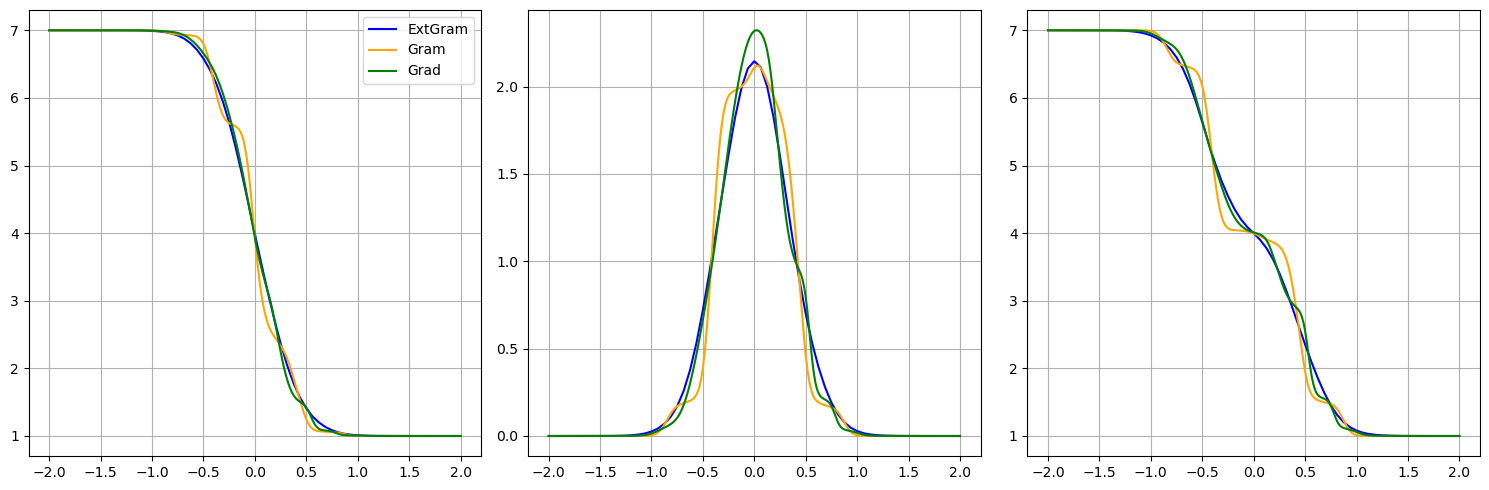

In [ ]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    for j, closure in enumerate(closure_vec):
        file = filename_moments(closure)
        x, u, _ = sol_final(file)
        axs[i].plot(x, u[:, i], color=colors[j], label=f"{closure}")

    # BGK
    x_bgk = data_bgk['x'].to_numpy()
    rho_bgk = data_bgk['rho'].to_numpy()
    if i == 0:
        u_bgk = rho_bgk:
    elseif i == 1:
        u_bgk = data_bgk['v'].to_numpy() 
    else:
        u_bgk = data_bgk['p'].to_numpy()
[ax.grid() for ax in axs]
axs[0].legend()
fig.tight_layout()
fig.show()